# WR MLP - Quantile Regression

Umesto klasicnog point estimate (MSE/Huber), treniramo MLP da predvidja **tri kvantila istovremeno**: q10, q50, q90, koristeci **pinball loss**.

Prednosti:
- **q50 (medijana) kao point prediction** je robusniji na outliere od proseka - cesto bolji MAE
- **Besplatne intervali neizvesnosti** (q90 - q10) - za NFL "boom or bust" utakmice ovo je dragoceno
- Model uci pravi oblik distribucije, ne samo jednu tacku

Arhitektura: ista kao MLP-B (5 slojeva [448, 128, 320, 448, 256], LayerNorm, dropout 0.5), ali sa **3-izlaznom glavom** i pinball loss-om.

Target: sqrt(yards), invert kroz `pred**2` na kraju.


---
## 1. Imports

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, time, random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, Model, Input
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
print(f'TensorFlow {tf.__version__}')


TensorFlow 2.21.0


---
## 2. Load Top-40 Features & Data

In [5]:
df = pd.read_csv('../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)

# Load the top 40 feature list from feature selection notebook
with open('../results/selected_features_top40.json', 'r') as f:
    feat_info = json.load(f)
feat_cols = feat_info['selected_features']
print(f'Loaded {len(feat_cols)} features from selected_features_top40.json')

# Basic temporal features used in comparison notebook
# (lag1, roll5 etc. should already exist in wr_all_weeks.csv from feature engineering)
missing = [c for c in feat_cols if c not in df.columns]
if missing:
    print(f'Missing columns in base csv: {missing[:5]}... ({len(missing)} total)')
    print('Falling back to recomputing like MLP comparison notebook expects.')
else:
    print('All features present.')


Loaded 40 features from selected_features_top40.json
Missing columns in base csv: ['first_downs_roll5', 'target_share_std_lag1', 'targets_roll5', 'air_yards_roll5', 'avg_yards_last_season']... (33 total)
Falling back to recomputing like MLP comparison notebook expects.


---
## 3. Recreate Top-40 Features (same pipeline as MLP comparison)


In [6]:
# Recreate the same pipeline as in WR_MLP_Comparison notebook
work_df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

# --- Rename WP columns ---
wp_rename_map = {
    'yards_wp_<25': 'yards_wp_less_than_25',
    'yards_wp_>75': 'yards_wp_greater_than_75',
    'receptions_wp_<25': 'receptions_wp_less_than_25',
    'receptions_wp_>75': 'receptions_wp_greater_than_75',
    'targets_wp_<25': 'targets_wp_less_than_25',
    'targets_wp_>75': 'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

# --- Infer player team and detect changes ---
work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan
    )
)
prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna() & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (
    prev_season.notna() & (work_df['season'] != prev_season)
).astype(int)

work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

# --- Previous-season career features ---
season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(
        avg_yards=('receiving_yards', 'mean'),
        avg_target_share=('target_share', 'mean'),
        avg_epa=('epa', 'mean'),
        avg_air_yard_share=('air_yard_share', 'mean'),
        avg_catch_rate=('catch_rate', 'mean'),
        games_played=('game_id', 'count')
    )
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)

# --- Lag1 and Roll5 features ---
rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]
available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []
for col in available_roll_cols:
    work_df[f'{col}_lag1'] = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])

# --- Momentum features ---
momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col = f'{col}_lag1'
    roll5_col = f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

# --- Interaction features ---
interaction_cols = []
if 'target_share_lag1' in work_df.columns and 'pregame_total' in work_df.columns:
    work_df['target_volume_interaction'] = (
        work_df['target_share_lag1'] * work_df['pregame_total']
    )
    interaction_cols.append('target_volume_interaction')
if 'air_yard_share_lag1' in work_df.columns and 'team_pass_attempts_lag1' in work_df.columns:
    work_df['air_yards_expected'] = (
        work_df['air_yard_share_lag1'] * work_df['team_pass_attempts_lag1']
    )
    interaction_cols.append('air_yards_expected')
if 'catch_rate_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['expected_receptions'] = (
        work_df['catch_rate_lag1'] * work_df['targets_lag1']
    )
    interaction_cols.append('expected_receptions')
if 'epa_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['epa_per_target'] = (
        work_df['epa_lag1'] / work_df['targets_lag1'].replace(0, np.nan)
    ).fillna(0)
    interaction_cols.append('epa_per_target')

# --- Drop rows with no prior history (matches comparison notebook) ---
lag1_cols_all = [c for c in derived_cols if c.endswith('_lag1')]
no_history = work_df[lag1_cols_all].isna().all(axis=1)
work_df = work_df.loc[~no_history].copy()
work_df = work_df.loc[:, ~work_df.columns.duplicated()]

# --- Verify all selected features are present ---
still_missing = [c for c in feat_cols if c not in work_df.columns]
if still_missing:
    print(f'Still missing after engineering: {still_missing}')
    raise ValueError('Feature pipeline mismatch - inspect selected_features_top40.json')

work_df[feat_cols] = work_df[feat_cols].fillna(0)
df = work_df
print(f'All {len(feat_cols)} selected features ready. Shape: {df.shape}')


All 40 selected features ready. Shape: (44396, 274)


---
## 4. Temporal Split & Scaling

In [7]:
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

tr_mask = df['season'].isin(train_seasons)
va_mask = df['season'].isin(val_seasons)
te_mask = df['season'].isin(test_seasons)

X_tr_raw = df.loc[tr_mask, feat_cols].values
X_va_raw = df.loc[va_mask, feat_cols].values
X_te_raw = df.loc[te_mask, feat_cols].values
y_tr = df.loc[tr_mask, 'receiving_yards'].values.astype(np.float32)
y_va = df.loc[va_mask, 'receiving_yards'].values.astype(np.float32)
y_te = df.loc[te_mask, 'receiving_yards'].values.astype(np.float32)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr_raw).astype(np.float32)
X_va = scaler.transform(X_va_raw).astype(np.float32)
X_te = scaler.transform(X_te_raw).astype(np.float32)

# Target transformation: sqrt
y_tr_s = np.sqrt(np.clip(y_tr, 0, None)).astype(np.float32)
y_va_s = np.sqrt(np.clip(y_va, 0, None)).astype(np.float32)
y_te_s = np.sqrt(np.clip(y_te, 0, None)).astype(np.float32)

print(f'train={len(y_tr)}  val={len(y_va)}  test={len(y_te)}')
print(f'Features: {X_tr.shape[1]}')


train=29276  val=8921  test=6199
Features: 40


---
## 5. Pinball Loss for Multiple Quantiles


In [8]:
QUANTILES = [0.1, 0.5, 0.9]
N_Q = len(QUANTILES)

def multi_pinball_loss(quantiles):
    q_tensor = tf.constant(quantiles, dtype=tf.float32)  # (N_Q,)
    def loss(y_true, y_pred):
        # y_true: (batch, 1)  y_pred: (batch, N_Q)
        y_true = tf.reshape(y_true, (-1, 1))  # (batch, 1)
        e = y_true - y_pred                   # (batch, N_Q)
        return tf.reduce_mean(tf.maximum(q_tensor * e, (q_tensor - 1) * e))
    return loss

# MAE of the median prediction - what we care about at inference
def median_mae(y_true, y_pred):
    y_true = tf.reshape(y_true, (-1, 1))
    median = y_pred[:, 1:2]
    return tf.reduce_mean(tf.abs(y_true - median))

print(f'Quantiles: {QUANTILES}')


Quantiles: [0.1, 0.5, 0.9]


---
## 6. MLP-B Architecture with 3-Output Head


In [9]:
def build_quantile_mlp(n_features, n_quantiles=3):
    units = [448, 128, 320, 448, 256]
    dropout = 0.5
    lr = 0.0037
    wd = 1.5e-5

    inp = Input(shape=(n_features,))
    x = inp
    for u in units:
        x = Dense(u, activation='relu')(x)
        x = LayerNormalization()(x)
        x = Dropout(dropout)(x)
    out = Dense(n_quantiles)(x)
    model = Model(inp, out)

    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=multi_pinball_loss(QUANTILES), metrics=[median_mae])
    return model

_m = build_quantile_mlp(X_tr.shape[1])
_m.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 448)            │        18,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 448)            │           896 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 320)            │        41,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 320)            │           640 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 448)            │       143,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 448)            │           896 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       114,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,843 (1.45 MB)

 Trainable params: 379,843 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

---
## 7. Train

In [10]:
def make_weights(strength, y_orig):
    mean_y = np.mean(np.clip(y_orig, 0, None))
    return 1.0 + strength * np.sqrt(np.clip(y_orig, 0, None) / mean_y)

sw_tr = make_weights(1.0, y_tr)

tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

model = build_quantile_mlp(X_tr.shape[1])

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=25,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=8, min_lr=1e-6),
]

t0 = time.time()
hist = model.fit(
    X_tr, y_tr_s,
    sample_weight=sw_tr,
    validation_data=(X_va, y_va_s),
    epochs=300, batch_size=32,
    callbacks=cb, verbose=1,
)
print(f'\nTrained in {time.time()-t0:.0f}s')



Epoch 1/300
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.2581 - median_mae: 2.1504 - val_loss: 0.6125 - val_median_mae: 1.9783 - learning_rate: 0.0037
Epoch 2/300
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1844 - median_mae: 2.0510 - val_loss: 0.6088 - val_median_mae: 1.9632 - learning_rate: 0.0037
Epoch 3/300
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1734 - median_mae: 2.0351 - val_loss: 0.6050 - val_median_mae: 1.9625 - learning_rate: 0.0037
Epoch 4/300
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1673 - median_mae: 2.0272 - val_loss: 0.6057 - val_median_mae: 1.9502 - learning_rate: 0.0037
Epoch 5/300
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1659 - median_mae: 2.0246 - val_loss: 0.6077 - val_median_mae: 1.9708 - learning_rate: 0.0037
Epoch 6/300
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1608 - median_mae: 2.0163 - val_loss: 0.6128 - val_median_mae: 1.9786 - learning_rate: 0.0037
Epoch 7/300
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

---
## 8. Evaluation - Point Metrics (using q50) & Quantile Coverage


In [11]:
pred_te = model.predict(X_te, verbose=0)  # (N, 3) in sqrt space
q10_sqrt = pred_te[:, 0]
q50_sqrt = pred_te[:, 1]
q90_sqrt = pred_te[:, 2]

# Invert sqrt transform
q10 = np.clip(q10_sqrt, 0, None) ** 2
q50 = np.clip(q50_sqrt, 0, None) ** 2
q90 = np.clip(q90_sqrt, 0, None) ** 2

# Fix crossing quantiles (rare but possible)
q10_fix = np.minimum(q10, q50)
q90_fix = np.maximum(q90, q50)

mae_q50 = mean_absolute_error(y_te, q50)
rmse_q50 = np.sqrt(mean_squared_error(y_te, q50))
r2_q50 = r2_score(y_te, q50)

coverage = np.mean((y_te >= q10_fix) & (y_te <= q90_fix))
interval_width = np.mean(q90_fix - q10_fix)

print(f'=== Quantile MLP (q50 as point prediction) ===')
print(f'  MAE:  {mae_q50:.2f}')
print(f'  RMSE: {rmse_q50:.2f}')
print(f'  R2:   {r2_q50:.4f}')
print(f'\n=== Uncertainty Interval (q90 - q10) ===')
print(f'  Coverage (target 80%): {coverage*100:.1f}%')
print(f'  Mean interval width:   {interval_width:.1f} yards')

print(f'\n=== Comparison ===')
print(f'  MLP-B (point estimate): MAE=18.19  RMSE=25.23  R2=0.3289')
print(f'  MLP Quantile (q50):     MAE={mae_q50:.2f}  RMSE={rmse_q50:.2f}  R2={r2_q50:.4f}')


=== Quantile MLP (q50 as point prediction) ===
  MAE:  17.76
  RMSE: 25.60
  R2:   0.3093

=== Uncertainty Interval (q90 - q10) ===
  Coverage (target 80%): 78.8%
  Mean interval width:   59.7 yards

=== Comparison ===
  MLP-B (point estimate): MAE=18.19  RMSE=25.23  R2=0.3289
  MLP Quantile (q50):     MAE=17.76  RMSE=25.60  R2=0.3093


---
## 9. Visualize Predictions + Intervals

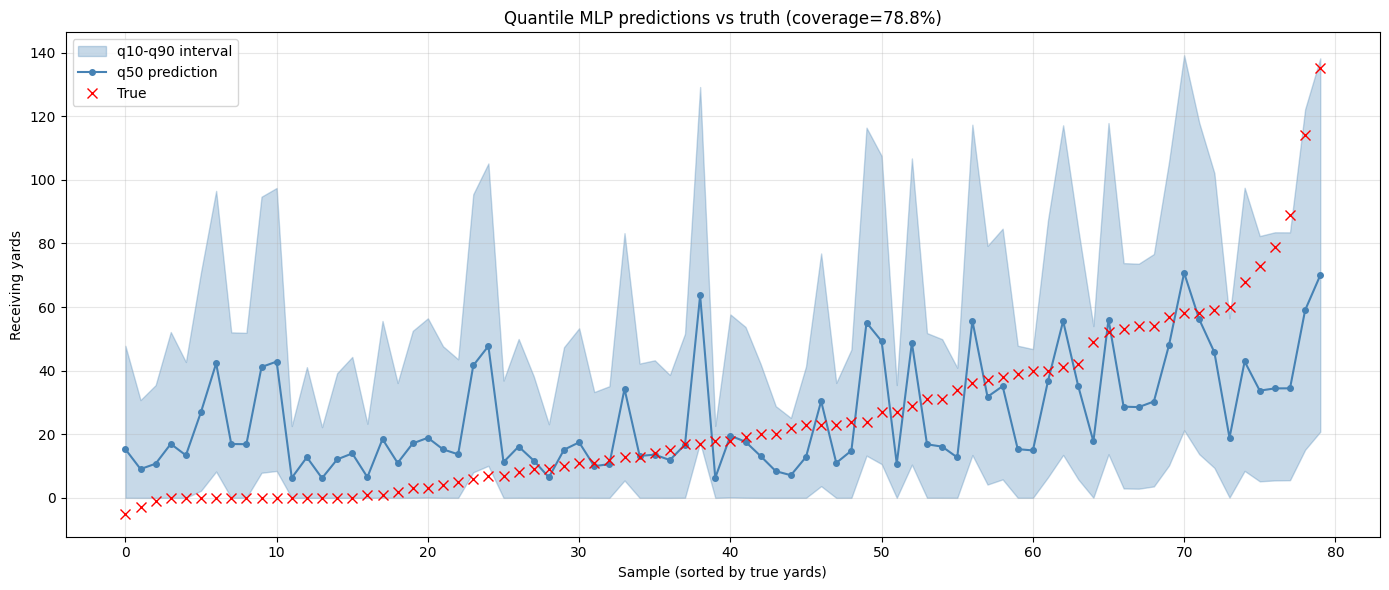

In [12]:
# Plot some samples with their q10-q90 intervals
np.random.seed(0)
idx = np.random.choice(len(y_te), 80, replace=False)
idx = idx[np.argsort(y_te[idx])]

fig, ax = plt.subplots(figsize=(14, 6))
xs = np.arange(len(idx))
ax.fill_between(xs, q10_fix[idx], q90_fix[idx], alpha=0.3, color='steelblue', label='q10-q90 interval')
ax.plot(xs, q50[idx], 'o-', color='steelblue', markersize=4, label='q50 prediction')
ax.plot(xs, y_te[idx], 'x', color='red', markersize=7, label='True')
ax.set_xlabel('Sample (sorted by true yards)')
ax.set_ylabel('Receiving yards')
ax.set_title(f'Quantile MLP predictions vs truth (coverage={coverage*100:.1f}%)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/mlp_quantile_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Learning Curve

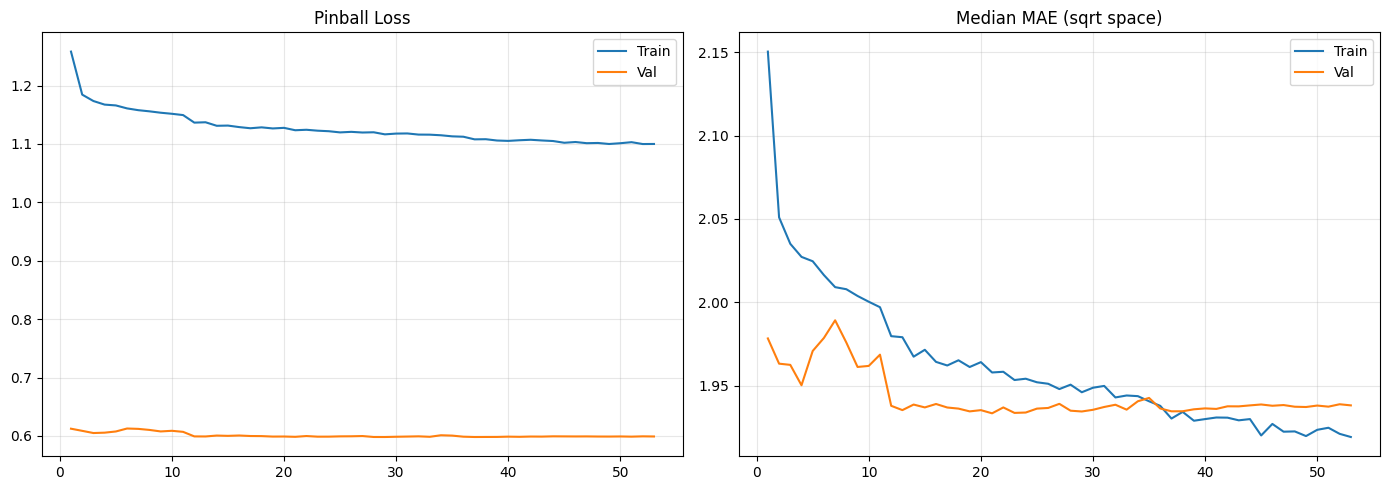

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(hist.history['loss']) + 1)
axes[0].plot(ep, hist.history['loss'], label='Train')
axes[0].plot(ep, hist.history['val_loss'], label='Val')
axes[0].set_title('Pinball Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, hist.history['median_mae'], label='Train')
axes[1].plot(ep, hist.history['val_median_mae'], label='Val')
axes[1].set_title('Median MAE (sqrt space)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/mlp_quantile_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Save Results

In [14]:
output = {
    'quantiles': QUANTILES,
    'test_metrics': {
        'mae_q50': float(mae_q50),
        'rmse_q50': float(rmse_q50),
        'r2_q50': float(r2_q50),
        'coverage_80pct': float(coverage),
        'mean_interval_width': float(interval_width),
    },
    'best_epoch': int(np.argmin(hist.history['val_loss']) + 1),
    'n_features': int(X_tr.shape[1]),
    'architecture': {
        'units': [448, 128, 320, 448, 256],
        'dropout': 0.5, 'lr': 0.0037, 'wd': 1.5e-5,
    },
    'comparison': {
        'MLP-B (point)':  {'mae': 18.19, 'rmse': 25.23, 'r2': 0.3289},
        'MLP-Quantile':   {'mae': round(mae_q50, 2), 'rmse': round(rmse_q50, 2), 'r2': round(r2_q50, 4)},
    },
}

with open('../results/mlp_quantile_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

print('Saved: results/mlp_quantile_results.json')


Saved: results/mlp_quantile_results.json
